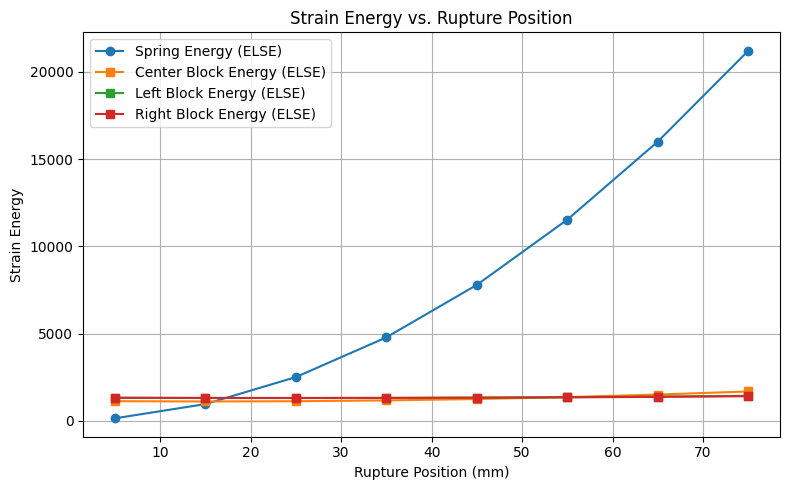

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

RUPTURE_POSITIONS = [75, 65, 55, 45, 35, 25, 15, 5]

spring_energies = []
center_block_energies = []
left_block_energies = []
right_block_energies = []

for pos in RUPTURE_POSITIONS:
    filename = f'./npz/strain-energy-{pos}.npz'
    if not os.path.exists(filename):
        print(f"[WARNING] File {filename} not found. Skipping.")
        continue

    data = np.load(filename)
    spring_energies.append(data.get('ELSE-Spring', np.nan))
    center_block_energies.append(data.get('ELSE-Center-Block', np.nan))
    left_block_energies.append(data.get('ELSE-Left-Block', np.nan))
    right_block_energies.append(data.get('ELSE-Right-Block', np.nan))

spring_energies = np.array(spring_energies)
center_block_energies = np.array(center_block_energies)

plt.figure(figsize=(8, 5))
plt.plot(RUPTURE_POSITIONS, spring_energies, 'o-', label='Spring Energy (ELSE)')
plt.plot(RUPTURE_POSITIONS, center_block_energies, 's-', label='Center Block Energy (ELSE)')
plt.plot(RUPTURE_POSITIONS, left_block_energies, 's-', label='Left Block Energy (ELSE)')
plt.plot(RUPTURE_POSITIONS, right_block_energies, 's-', label='Right Block Energy (ELSE)')
plt.xlabel('Rupture Position (mm)')
plt.ylabel('Strain Energy')
plt.title('Strain Energy vs. Rupture Position')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()